In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("Cardiotocographic.csv")

df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [3]:
df.shape
df.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')

In [4]:
df.info()
df.isnull().sum()
df.fillna(df.mean(), inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [5]:
df.describe()
df.median()
df.std()
df.quantile(0.75) - df.quantile(0.25)

LB          14.000000
AC           0.005606
FM           0.002567
UC           0.004685
DL           0.003289
DS           0.000000
DP           0.000000
ASTV        29.000000
MSTV         1.000000
ALTV        11.000000
MLTV         6.200000
Width       63.000000
Tendency     1.000000
NSP          0.000000
dtype: float64

In [6]:
df.dtypes
df["LB"] = pd.to_numeric(df["LB"], errors="coerce")

# Data Distribution Analysis

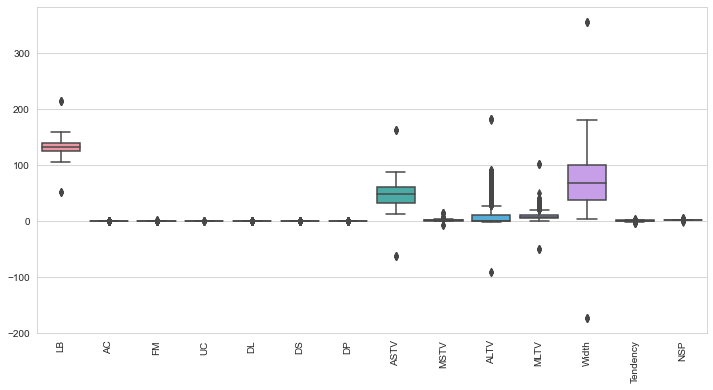

In [7]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# Outlier Analysis

In [8]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

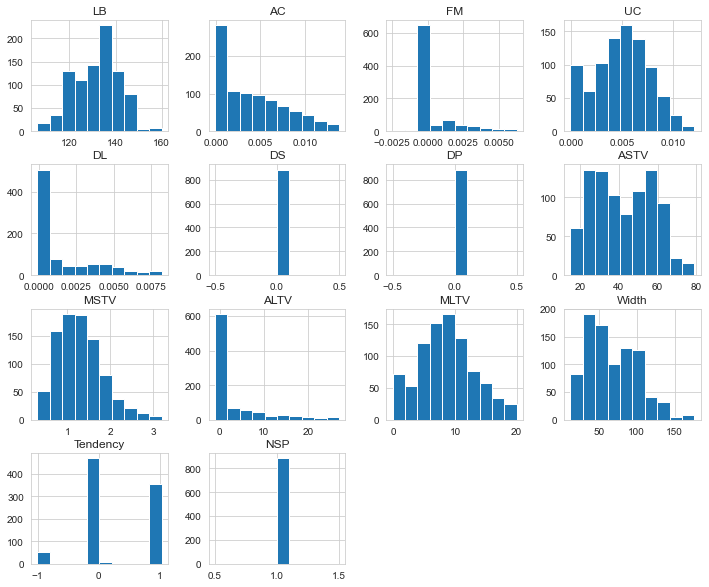

In [9]:
df.hist(figsize=(12,10))
plt.show()

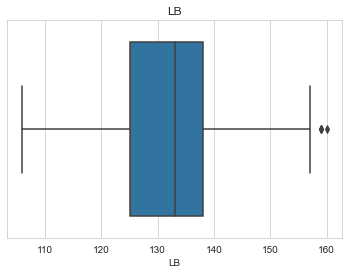

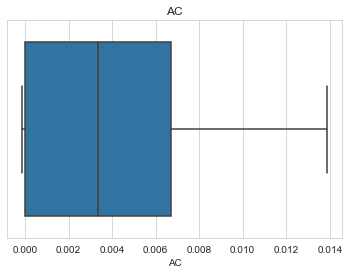

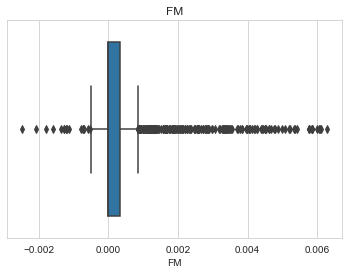

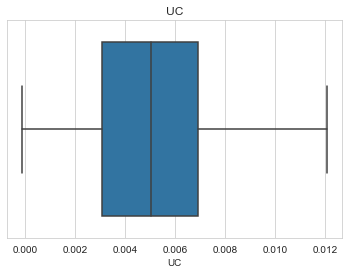

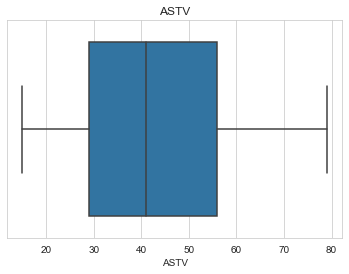

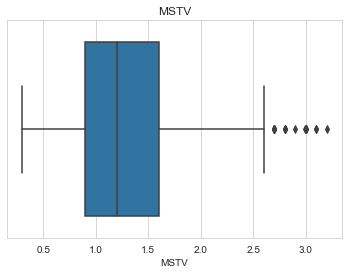

In [10]:
cols = ["LB","AC","FM","UC","ASTV","MSTV"]

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Heat Maps - Correlation Insights

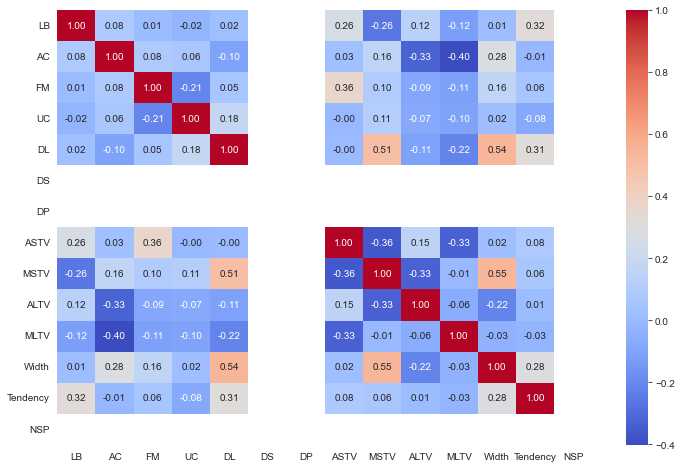

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.show()

# Feature Relationships - Scatter Analysis

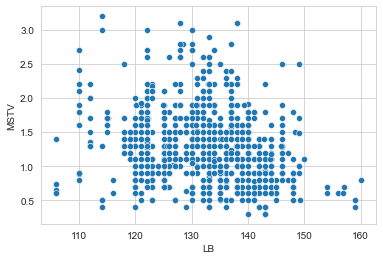

In [12]:
sns.scatterplot(
    x=df["LB"],
    y=df["MSTV"]
)

plt.show()

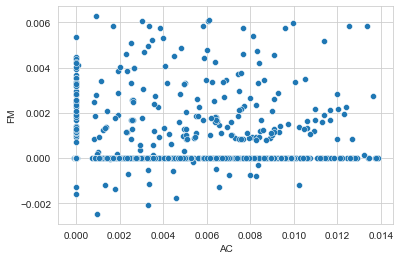

In [13]:
sns.scatterplot(
    x=df["AC"],
    y=df["FM"]
)

plt.show()

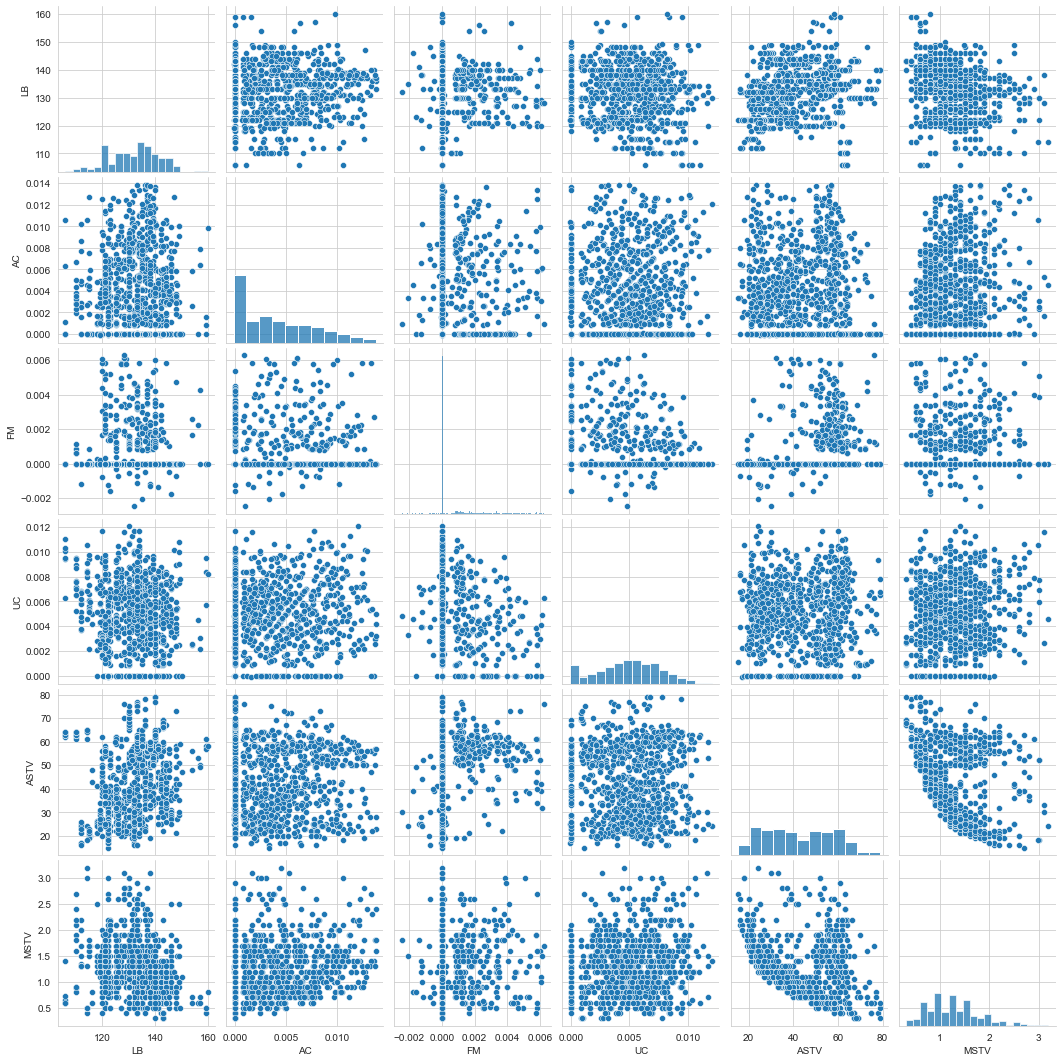

In [14]:
sns.pairplot(df[
    ["LB","AC","FM","UC","ASTV","MSTV"]
])

plt.show()

# Distribution Shape Observations

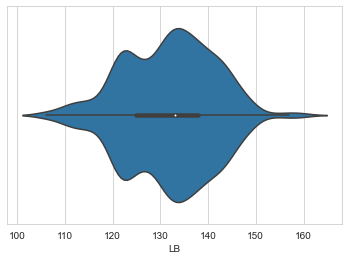

In [16]:
sns.violinplot(x=df["LB"])
plt.show()

# Summary

The dataset shows a mix of normally distributed and highly skewed features. Variables like LB and ASTV are relatively well-distributed, while FM, DL, DS, and DP are heavily skewed with many zero values, indicating sparse occurrences. Boxplots reveal significant outliers, especially in FM, MSTV, and Width, which may affect model performance if not handled properly. Correlation analysis indicates mostly weak relationships between variables, with a few moderate correlations such as MSTV with Width and ASTV with MSTV. Scatter plots suggest the absence of strong linear relationships, pointing toward possible non-linear patterns in the data. The target variable (NSP) appears imbalanced, with one class dominating the distribution. Overall, the dataset contains noise, skewness, and outliers that require preprocessing. Techniques like log transformation, outlier handling, and feature scaling are recommended. Due to weak linear correlations, non-linear models like Decision Trees or Random Forests may perform better. Handling class imbalance using methods like SMOTE or class weighting is also necessary. Proper preprocessing and model selection will be key to achieving accurate predictions.